# Upscale — six strategies, measured the way an eye sees

`upscale_web.ipynb` took one architecture and made it fast. This notebook asks the other
question: **is that architecture the right one**, and it changes the instrument before
asking, because the old one was answering about the wrong thing.

## The measurement changed first

Every dB in this folder so far is RGB PSNR: the squared error of three channels, counted
equally. An eye does not count them equally. Luminance carries the detail it resolves —
edges, text, the structure it judges sharpness by — and chrominance carries far less,
which is why every codec in use throws away three quarters of the chroma samples (4:2:0)
and nobody notices, and why nobody does that to luma.

So `metrics.py` scores in Y'CbCr instead, keeps the three channels apart, and weights the
**errors** 6:1:1 before taking the logarithm — a chroma error counts one sixth of a luma
error of the same size. Beside it: `psnr-y` alone, which is what super-resolution work
usually reports, and `ssim-y`, because every error metric in the family rewards blur and
something in the table should not.

The demonstration is in phase 1 and it is blunt. Two corrupted copies of the same patch,
equal error energy, one in luma and one in chroma: **RGB PSNR calls the chroma damage the
worse of the two** (25.8 dB against 26.1), and the chroma damage is the one that is
nearly invisible — its luma SSIM is 0.999 against 0.562. The weighted score separates
them by 8.1 dB, in the direction an eye would.

## Six strategies, one budget

All six keep `upscale_web`'s frame: a frozen bicubic skip written as a `Conv`, a residual
predicted at low resolution, one `DepthToSpace`. They differ in what happens between,
and they are held to roughly the same multiply-accumulate budget so the comparison is
about shape rather than size:

1. **The loss follows the metric** — the shipped 32-16 body, trained on a luma-weighted
   L1 instead of an RGB one. No architectural change at all; it is the control that says
   how much of any gain below is the objective rather than the network.
2. **Split the colour** — convert to Y'CbCr with a fixed 1×1 convolution, give luma a
   wide branch and chroma a narrow one, convert back with the inverse. Capacity follows
   the metric instead of being spread evenly over three channels the eye reads unevenly.
   Two variants, because the first raises a question the second answers: whether the
   luma branch should see its own channel alone, or all three.
3. **Reparameterization** — train each convolution as three parallel branches and
   collapse them into one 3×3 for export. 4.4× the arithmetic while learning, and the
   reference model's exact graph — four convolutions — when it runs.
4. **Recursion** — one shared 3×3 applied three times: depth without parameters.
5. **Dense cascade** — every layer sees the concatenation of all the layers before it.
6. **Channel attention** — a squeeze-and-excite gate on the wide feature, which is the
   one candidate here that leaves the WebGPU op budget.

That is six ideas over eight training runs, plus two extra runs of the control at other
seeds — because a table of eight numbers read off 76 validation patches needs to say how
wide a coin toss is before any of its gaps mean anything.

Same data, same recipe, same seed, same halo discipline, and every published one exported
and timed through the runtime that would run it, so the cost column is a measurement
rather than a parameter count.

In [2]:
"""Configuration — every knob this notebook has."""

from pathlib import Path

DATA_DIR = Path("data/processed")
RAW_DIR = Path("data/raw")
CHECKPOINT_DIR = Path("checkpoints")
SAMPLE_DIR = Path("data/samples")

# The reference body, from `upscale_web`. Every other strategy is sized against its cost.
WIDTHS = (32, 16)
STEM = 5                       # first kernel; the skip uses the same reach
SKIP = 5                       # a x2 bicubic filter needs 4 taps, so 5 is the smallest odd fit

EPOCHS = 100
BATCH_SIZE = 32
LEARNING_RATE = 1e-3
SEED = 0

# What gets published to the benchmark page at the end: the best strategy, and the control
# it has to beat.
PUBLISH = 2

In [3]:
"""Imports, device, and the manifest the preprocessing notebook wrote."""

import json
import time

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt

import metrics
import webexport

torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLE_DIR.mkdir(parents=True, exist_ok=True)

if not (DATA_DIR / "manifest.json").exists():
    raise RuntimeError(f"no dataset in {DATA_DIR} — run data_preprocess.ipynb first")

manifest = json.loads((DATA_DIR / "manifest.json").read_text(encoding="utf-8"))
SCALE = manifest["scale"]

print("device      ", DEVICE, torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")
print("torch       ", torch.__version__)
print("scale       ", SCALE)
print("patch       ", manifest["patch_lr"], "->", manifest["patch_hr"])
print("metric      ", f"weighted {':'.join(str(int(w)) for w in metrics.WEIGHTS)} over Y, U, V")

device       cpu 
torch        2.13.0+cpu
scale        2
patch        64 -> 128
metric       weighted 6:1:1 over Y, U, V


## 1. The measurement

The claim is that RGB PSNR is the wrong instrument for a picture that will be looked at.
It is cheap to show rather than assert: take one validation patch, damage it twice with
the *same amount* of error — once in luma, once in chroma — and score both.

The two corruptions are equal in energy by construction: the same noise field is added to
Y in one copy and to U in the other, and both are converted back to RGB. Nothing about
the error changes except which channel carries it.

                    wpsnr   psnr-y   psnr-u   psnr-v  psnr-rgb   ssim-y
luma damaged        27.34    26.09    55.89    50.77     26.12   0.5620
chroma damaged      35.47    58.18    26.46    62.13     25.84   0.9989

the same error energy, in the channel an eye reads and in one it barely does:
RGB PSNR ranks the invisible damage as the worse of the two


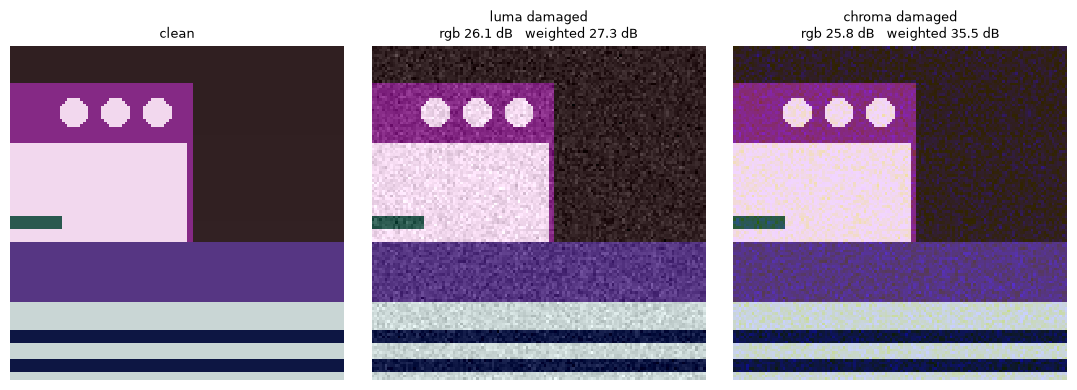

In [5]:
"""One patch, damaged twice with equal energy, scored by both instruments."""

val_lr = np.load(DATA_DIR / manifest["splits"]["val"]["lr"])
val_hr = np.load(DATA_DIR / manifest["splits"]["val"]["hr"])

to_tensor = lambda a: torch.from_numpy(a.transpose(2, 0, 1)[None].copy()).float().div_(255.0)
clean = to_tensor(val_hr[3])

generator = torch.Generator().manual_seed(SEED)
noise = torch.randn(1, 1, *clean.shape[2:], generator=generator) * 0.05
zero = torch.zeros_like(noise)
damaged = {
    "luma damaged": metrics.yuv_to_rgb(metrics.rgb_to_yuv(clean) + torch.cat([noise, zero, zero], 1)),
    "chroma damaged": metrics.yuv_to_rgb(metrics.rgb_to_yuv(clean) + torch.cat([zero, noise, zero], 1)),
}

print(f"{'':<16}{metrics.HEADER}")
for name, image in damaged.items():
    print(f"{name:<16}{metrics.row(metrics.report(image, clean))}")

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
panels = {"clean": clean, **damaged}
for ax, (name, image) in zip(axes, panels.items()):
    ax.imshow(image[0].clamp(0, 1).permute(1, 2, 0).numpy(), interpolation="nearest")
    scores = metrics.report(image, clean)
    ax.set_title(name if name == "clean" else
                 f"{name}\nrgb {scores['rgb']:.1f} dB   weighted {scores['wpsnr']:.1f} dB",
                 fontsize=9)
    ax.axis("off")
fig.tight_layout()
plt.show()

print("\nthe same error energy, in the channel an eye reads and in one it barely does:")
print("RGB PSNR ranks the invisible damage as the worse of the two")

### What the weighting is, precisely

Two ways to combine three channels into one number, and they are different functions:

- `wpsnr` weights the **errors** 6:1:1 and takes one logarithm. A chroma error counts a
  sixth of a luma error of the same size — the perceptual claim written as arithmetic.
  This is the column this repo reports.
- `wpsnr_db` averages the three **dB** figures 6:1:1, which is the convention published
  numbers use. Averaging logarithms is a geometric mean of the errors, so one very
  accurate channel lifts the whole score; weighting the errors does not allow that.

And one more knob with a physical reason behind it: chroma is transmitted at a quarter of
the samples, so an error finer than the chroma grid does not survive the encoder. Scoring
chroma after a 2×2 average is closer to what will actually be delivered, and it is what
`chroma_subsample=2` does.

In [7]:
"""The same two corruptions under all three ways of asking."""

print(f"{'':<16}{'wpsnr':>10}{'wpsnr_db':>11}{'wpsnr 4:2:0':>14}{'rgb':>9}")
for name, image in damaged.items():
    print(f"{name:<16}{metrics.wpsnr(image, clean):10.2f}{metrics.wpsnr_db(image, clean):11.2f}"
          f"{metrics.wpsnr(image, clean, chroma_subsample=2):14.2f}{metrics.psnr(image, clean):9.2f}")

print("\nthe dB average is the softer of the two on chroma damage, which is why the")
print("error weighting is the headline: a sixth of the weight, before the logarithm")

                     wpsnr   wpsnr_db   wpsnr 4:2:0      rgb
luma damaged         27.34      32.90         27.34    26.12
chroma damaged       35.47      54.71         41.36    25.84

the dB average is the softer of the two on chroma damage, which is why the
error weighting is the headline: a sixth of the weight, before the logarithm


## 2. Data

The same patch pairs as the other notebooks — memory-mapped `.npy`, the eight-way
flip/rotate augmentation on the training split only, `val` held out by source frame.
`data_preprocess.ipynb` carries the reasoning; this one only needs the loaders.

In [9]:
"""Patch pairs as float tensors in [0, 1], with the flip/rotate augmentation."""

class PatchPairs(Dataset):
    def __init__(self, directory, split, manifest, augment):
        info = manifest["splits"][split]
        self.split = split
        self.frames = info["frames"]
        self.lr = np.load(directory / info["lr"], mmap_mode="r")
        self.hr = np.load(directory / info["hr"], mmap_mode="r")
        self.augment = augment

    def __len__(self):
        return len(self.lr)

    def __getitem__(self, index):
        lr = np.asarray(self.lr[index])
        hr = np.asarray(self.hr[index])

        if self.augment:
            turns = int(torch.randint(0, 4, ()))
            lr, hr = np.rot90(lr, turns), np.rot90(hr, turns)
            if int(torch.randint(0, 2, ())):
                lr, hr = lr[:, ::-1], hr[:, ::-1]

        as_tensor = lambda a: torch.from_numpy(
            np.ascontiguousarray(a.transpose(2, 0, 1))).float().div_(255.0)
        return as_tensor(lr), as_tensor(hr)


train_set = PatchPairs(DATA_DIR, "train", manifest, augment=True)
val_set = PatchPairs(DATA_DIR, "val", manifest, augment=False)

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)
val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False)

print(f"{'split':>6}{'patches':>9}{'frames':>8}{'batches':>9}  augment")
for dataset, loader in [(train_set, train_loader), (val_set, val_loader)]:
    print(f"{dataset.split:>6}{len(dataset):9}{len(dataset.frames):8}{len(loader):9}"
          f"  {'yes' if dataset.augment else 'no'}")

 split  patches  frames  batches  augment
 train      268      10        8  yes
   val       76       2        3  no


## 3. Six strategies

### What they all share

Every model below is the same three-part shape, inherited from `upscale_web` because
each part of it was already paid for:

- a **frozen bicubic skip written as a convolution**, so the graph carries no `Resize`
  (48 ms a tile on the CPU runtime, and outside the WebGPU op budget) and an untrained
  model *is* the bicubic baseline;
- a body that predicts a **residual at low resolution**, where there are a quarter as
  many elements as at the output;
- one `PixelShuffle` at the end, shared by both branches because `DepthToSpace` is
  linear and `DTS(a) + DTS(b) = DTS(a + b)`.

What differs is the body, and the class below is the only thing they have in common.

In [11]:
"""The bicubic filter recovered from the operator it replaces, and the shape around it."""

def bicubic(x, scale=None):
    return F.interpolate(x, scale_factor=scale or SCALE, mode="bicubic", align_corners=False)


def bicubic_kernel(scale=SCALE, size=SKIP):
    """The x2 bicubic upsampling filter as `scale²` kernels, one per output phase.

    Recovered rather than derived: the operator is linear, so pushing a unit impulse
    through `F.interpolate` at every position of a `size`x`size` window reads its weights
    straight out of it - no cubic formula, and no guess about which `a` torch uses.
    """
    impulse = torch.zeros(1, 1, size, size)
    weights = torch.zeros(scale * scale, size, size)
    centre = size // 2
    for y in range(size):
        for x in range(size):
            impulse.zero_()
            impulse[0, 0, y, x] = 1.0
            out = bicubic(impulse, scale)[0, 0]
            for dy in range(scale):
                for dx in range(scale):
                    weights[dy * scale + dx, y, x] = out[centre * scale + dy, centre * scale + dx]
    return weights


class BicubicSkip(nn.Module):
    """Bicubic x2 as one convolution, so the graph carries no Resize."""

    def __init__(self, scale=SCALE, size=SKIP, trainable=False):
        super().__init__()
        self.conv = nn.Conv2d(3, 3 * scale * scale, size, padding=size // 2, bias=False)
        phases = bicubic_kernel(scale, size)
        weight = torch.zeros_like(self.conv.weight)
        for channel in range(3):
            for phase in range(scale * scale):
                # Each colour keeps to itself; the cross terms stay zero.
                weight[channel * scale * scale + phase, channel] = phases[phase]
        with torch.no_grad():
            self.conv.weight.copy_(weight)
        self.conv.weight.requires_grad_(trainable)

    def forward(self, x):
        return self.conv(x)


class Upscaler(nn.Module):
    """A frozen bicubic skip, a residual predicted at LR, one shuffle. Subclasses fill in
    `residual`, and nothing else about the frame is theirs to change."""

    def __init__(self, scale=SCALE, skip=SKIP):
        super().__init__()
        self.scale = scale
        self.skip = BicubicSkip(scale, skip)
        self.shuffle = nn.PixelShuffle(scale)
        self.skip_reach = skip // 2

    def reach(self, stem, threes):
        """The halo: `stem // 2` for the first kernel and one more per 3x3 after it - the
        tail counts, and forgetting it is how a model tiles with a seam - and never less
        than the frozen skip's own reach."""
        return max(stem // 2 + threes, self.skip_reach)

    def residual(self, x):
        raise NotImplementedError

    def forward(self, x):
        return self.shuffle(self.skip(x) + self.residual(x))


def zero_start(tail):
    """The last convolution starts at zero, so epoch 0 measures exactly the baseline."""
    nn.init.zeros_(tail.weight)
    nn.init.zeros_(tail.bias)
    return tail


def sequence(widths, channels, stem, activation=nn.ReLU):
    """`stem`x`stem` first, 3x3 after, ReLU between - the body every strategy starts from."""
    layers = []
    for index, width in enumerate(widths):
        kernel = stem if index == 0 else 3
        layers += [nn.Conv2d(channels, width, kernel, padding=kernel // 2), activation(inplace=True)]
        channels = width
    return nn.Sequential(*layers), channels


probe = torch.rand(1, 3, 24, 24)
rebuilt = nn.PixelShuffle(SCALE)(BicubicSkip()(probe))
edge = 2 * SKIP
difference = (rebuilt[..., edge:-edge, edge:-edge]
              - bicubic(probe)[..., edge:-edge, edge:-edge]).abs().max().item()
assert difference < 1e-5, difference
print(f"conv skip vs F.interpolate: max abs difference {difference:.1e} in the interior")

conv skip vs F.interpolate: max abs difference 2.4e-07 in the interior


### 1 — the control, and the loss that follows the metric

`upscale_web`'s body, unchanged: 5×5 to 32 channels, 3×3 to 16, a 3×3 tail to the twelve
phase channels. It is trained twice, once on RGB L1 and once on the luma-weighted L1 from
`metrics.py`, and the pair is the control for everything after it — a strategy that beats
the RGB-trained model but not the luma-trained one has bought nothing but the objective.

The loss weights the *error* rather than the channel, so it stays an L1 and the only
change is that a chroma pixel's gradient is a sixth of a luma pixel's.

In [13]:
"""Strategy 1: the reference body."""

class Baseline(Upscaler):
    def __init__(self, widths=WIDTHS, stem=STEM, **rest):
        super().__init__(**rest)
        self.body, width = sequence(widths, 3, stem)
        self.tail = zero_start(nn.Conv2d(width, 3 * self.scale ** 2, 3, padding=1))
        self.halo = self.reach(stem, len(widths))

    def residual(self, x):
        return self.tail(self.body(x))

### 2 — split the colour, and spend the capacity where the eye is

If the metric says luma is worth six times chroma, the network can be built to agree
rather than left to discover it. The input is converted to Y'CbCr by a **fixed 1×1
convolution** — the colour transform is a per-pixel linear map, which is exactly what a
1×1 convolution is, so it costs 9 multiply-accumulates a pixel and stays inside the op
budget — and then two branches run on it:

- **luma**, 32-16 over the Y channel alone, producing the four Y phases;
- **chroma**, 8-4 over all three channels, producing the eight U and V phases. It sees
  luma because chroma prediction from luma structure is the one direction that helps;
  nothing goes back the other way.

Y reaches the luma branch through its own one-row 1×1 convolution rather than through a
slice of the converted tensor, and that is not a style choice: `x[:, :1]` exports as
`Slice`, which is outside the op budget, so saving nine multiply-accumulates a pixel
would have cost the branch its place on the fast path.

The two never mix again: the inverse transform is another fixed convolution, and it is
what turns the twelve Y'CbCr phase channels back into the RGB residual the skip is
waiting for. That is the point of freezing both ends — with a trainable layer there the
split would be a suggestion, since a linear map at the end of a linear tail is absorbed
into it. Frozen, the chroma branch *cannot* affect luma, and the budget split is real.

The inverse matrix is inverted from the forward one in float64 rather than quoted from
the four-decimal published coefficients, which is worth 2e-05 on a round trip through
both convolutions.

The narrow variant hands the luma branch one channel, which is what the split is *for*:
the stem drops from 3 input channels to 1 and the whole model comes in under the
reference budget. Whether that is a saving or a loss of information is exactly the
question, so `luma sees 3` runs the same split with the luma branch reading all of
Y'CbCr — the same MACs as the reference, spent in a different shape — and the pair of
them is the answer.

In [15]:
"""Strategy 2: luma and chroma, sized differently on purpose."""

class YuvSplit(Upscaler):
    def __init__(self, luma=(32, 16), chroma=(8, 4), luma_sees=1, stem=STEM, **rest):
        super().__init__(**rest)
        phases = self.scale ** 2

        # `luma_sees` is the question the two variants ask: 1 gives the luma branch its own
        # channel and nothing else, 3 gives it all of Y'CbCr at three times the stem cost.
        self.luma_sees = luma_sees
        self.to_luma = self.luma_row(metrics.RGB_TO_YUV)
        self.to_yuv = self.colour(metrics.RGB_TO_YUV, 1)
        self.luma_body, luma_width = sequence(luma, luma_sees, stem)
        self.luma_tail = zero_start(nn.Conv2d(luma_width, phases, 3, padding=1))
        self.chroma_body, chroma_width = sequence(chroma, 3, stem)
        self.chroma_tail = zero_start(nn.Conv2d(chroma_width, 2 * phases, 3, padding=1))
        # The inverse acts on phase channels, so it is the same 3x3 matrix repeated once
        # per phase - block structure written into a 12x12 kernel of mostly zeros.
        self.to_rgb = self.colour(metrics.YUV_TO_RGB, phases)

        self.halo = self.reach(stem, max(len(luma), len(chroma)))

    @staticmethod
    def luma_row(matrix):
        """Y alone, as a 1x1 convolution rather than a slice of the converted tensor.

        `x[:, :1]` is three multiply-accumulates cheaper and one operator worse: it exports
        as `Slice`, which is outside the WebGPU op budget, and taking the branch off the
        fast path to save nine MACs a pixel would be the worst trade in this folder.
        """
        conv = nn.Conv2d(3, 1, 1, bias=False)
        with torch.no_grad():
            conv.weight.copy_(matrix[0].view(1, 3, 1, 1))
        conv.weight.requires_grad_(False)
        return conv

    @staticmethod
    def colour(matrix, phases):
        """A colour transform as a frozen 1x1 convolution over `phases` interleaved copies."""
        conv = nn.Conv2d(3 * phases, 3 * phases, 1, bias=False)
        weight = torch.zeros_like(conv.weight)
        for out_channel in range(3):
            for in_channel in range(3):
                for phase in range(phases):
                    weight[out_channel * phases + phase, in_channel * phases + phase] = \
                        matrix[out_channel, in_channel]
        with torch.no_grad():
            conv.weight.copy_(weight)
        conv.weight.requires_grad_(False)
        return conv

    def residual(self, x):
        yuv = self.to_yuv(x)
        luma = self.luma_tail(self.luma_body(yuv if self.luma_sees == 3 else self.to_luma(x)))
        chroma = self.chroma_tail(self.chroma_body(yuv))
        return self.to_rgb(torch.cat([luma, chroma], dim=1))

### 3 — reparameterization: capacity while training, one convolution when it runs

A convolution followed by nothing is linear, and a *sum of parallel* convolutions over
the same input is one convolution too — its kernel is the sum of theirs. So a layer can
be three layers while it learns and one layer when it runs, at bit-identical arithmetic.
Each 3×3 here is trained as:

- the 3×3 itself,
- a 1×1, which learns a pure channel mixing free of any spatial prior,
- and a 1×1 expansion to 4× the width followed by a 3×3, which is a low-rank path with
  far more parameters than either.

`collapse()` folds all three into one 3×3: the 1×1 is padded into the centre tap, and the
sequential pair composes as `W_eq[o,i] = Σ_m W_3x3[o,m] * W_1x1[m,i]`. The notebook does
not take that on trust — it asserts the collapsed model matches the trained one.

One detail decides whether the collapse is exact or merely close: **the expansion's 1×1
carries no bias.** With a bias, the 3×3 after it pads with zeros where the true composed
operator would pad with that bias, and the two differ in a one-pixel ring — small, real,
and exactly the kind of border error that tiling would tile.

In [17]:
"""Strategy 3: three branches that become one."""

class RepConv(nn.Module):
    """A convolution trained as three parallel branches, collapsible into one."""

    def __init__(self, in_channels, out_channels, kernel=3, expand=4):
        super().__init__()
        self.kernel = kernel
        self.conv = nn.Conv2d(in_channels, out_channels, kernel, padding=kernel // 2)
        self.point = nn.Conv2d(in_channels, out_channels, 1)
        # No bias on the expansion: a bias here would be padded with zeros by the 3x3 that
        # follows, which is not what the collapsed kernel does at the border.
        self.expand = nn.Sequential(
            nn.Conv2d(in_channels, in_channels * expand, 1, bias=False),
            nn.Conv2d(in_channels * expand, out_channels, kernel, padding=kernel // 2))

    def forward(self, x):
        return self.conv(x) + self.point(x) + self.expand(x)

    @torch.no_grad()
    def collapse(self):
        """The one convolution these three branches add up to."""
        merged = nn.Conv2d(self.conv.in_channels, self.conv.out_channels, self.kernel,
                           padding=self.kernel // 2)
        centre = self.kernel // 2
        weight = self.conv.weight.clone()
        weight[:, :, centre, centre] += self.point.weight[:, :, 0, 0]

        first, second = self.expand[0].weight, self.expand[1].weight
        weight += torch.einsum("omuv,mi->oiuv", second, first[:, :, 0, 0])

        bias = self.conv.bias + self.point.bias + self.expand[1].bias
        merged.weight.copy_(weight)
        merged.bias.copy_(bias)
        return merged


class Reparameterized(Upscaler):
    def __init__(self, widths=WIDTHS, stem=STEM, expand=4, **rest):
        super().__init__(**rest)
        layers, channels = [], 3
        for index, width in enumerate(widths):
            kernel = stem if index == 0 else 3
            layers += [RepConv(channels, width, kernel, expand), nn.ReLU(inplace=True)]
            channels = width
        self.body = nn.Sequential(*layers)
        self.tail = zero_start(nn.Conv2d(channels, 3 * self.scale ** 2, 3, padding=1))
        self.halo = self.reach(stem, len(widths))

    def residual(self, x):
        return self.tail(self.body(x))

    @torch.no_grad()
    def collapsed(self):
        """The same model as plain convolutions - what actually gets exported."""
        merged = Baseline(tuple(m.conv.out_channels for m in self.body if isinstance(m, RepConv)),
                          stem=self.body[0].kernel, scale=self.scale)
        for source, target in zip([m for m in self.body if isinstance(m, RepConv)],
                                  [m for m in merged.body if isinstance(m, nn.Conv2d)]):
            collapsed = source.collapse()
            target.weight.copy_(collapsed.weight)
            target.bias.copy_(collapsed.bias)
        merged.tail.weight.copy_(self.tail.weight)
        merged.tail.bias.copy_(self.tail.bias)
        return merged.to(next(self.parameters()).device)

### 4, 5, 6 — depth without parameters, features that accumulate, and a gate

**Recursive** applies one shared 3×3 three times, each time adding its input back. It has
roughly half the parameters of the reference body at the same multiply-accumulate cost,
which is the trade a *download* cares about and an inference budget does not — worth
knowing which one this problem rewards.

**Dense** concatenates: every layer sees every earlier feature map, so the tail reads the
stem's output directly rather than through two lossy re-mixings. `Concat` is in the op
budget, and the growth rate keeps the cost near the reference.

**Attention** is squeeze-and-excite on the wide feature: average the whole tile per
channel, push it through a two-layer bottleneck, and scale each channel by the result. It
is nearly free in arithmetic and it is the one strategy here that leaves the op budget —
`GlobalAveragePool`, `Sigmoid` and `Mul` are not in it. It also does something the others
do not: it makes the output depend on the *whole tile*, so two tilings of the same frame
no longer agree, and the halo stops being a complete account of the tiling error.

In [19]:
"""Strategies 4, 5 and 6."""

class Recursive(Upscaler):
    def __init__(self, width=16, steps=3, stem=STEM, **rest):
        super().__init__(**rest)
        self.steps = steps
        self.stem = nn.Conv2d(3, width, stem, padding=stem // 2)
        self.cell = nn.Conv2d(width, width, 3, padding=1)
        self.tail = zero_start(nn.Conv2d(width, 3 * self.scale ** 2, 3, padding=1))
        self.halo = self.reach(stem, steps + 1)

    def residual(self, x):
        h = F.relu(self.stem(x))
        for _ in range(self.steps):
            h = F.relu(self.cell(h)) + h
        return self.tail(h)


class Dense(Upscaler):
    def __init__(self, width=14, growth=12, layers=2, stem=STEM, **rest):
        super().__init__(**rest)
        self.stem = nn.Conv2d(3, width, stem, padding=stem // 2)
        self.layers = nn.ModuleList(
            [nn.Conv2d(width + index * growth, growth, 3, padding=1) for index in range(layers)])
        self.tail = zero_start(
            nn.Conv2d(width + layers * growth, 3 * self.scale ** 2, 3, padding=1))
        self.halo = self.reach(stem, layers + 1)

    def residual(self, x):
        features = [F.relu(self.stem(x))]
        for layer in self.layers:
            features.append(F.relu(layer(torch.cat(features, dim=1))))
        return self.tail(torch.cat(features, dim=1))


class Attention(Upscaler):
    def __init__(self, widths=WIDTHS, stem=STEM, squeeze=4, **rest):
        super().__init__(**rest)
        self.body, width = sequence(widths, 3, stem)
        self.gate = nn.Sequential(nn.Conv2d(widths[0], widths[0] // squeeze, 1), nn.ReLU(),
                                  nn.Conv2d(widths[0] // squeeze, widths[0], 1), nn.Sigmoid())
        self.tail = zero_start(nn.Conv2d(width, 3 * self.scale ** 2, 3, padding=1))
        self.halo = self.reach(stem, len(widths))

    def residual(self, x):
        wide = self.body[1](self.body[0](x))
        gated = wide * self.gate(wide.mean(dim=(2, 3), keepdim=True))
        return self.tail(self.body[3](self.body[2](gated)))


STRATEGIES = {
    "32-16 rgb l1": (Baseline, {}, F.l1_loss),
    "32-16 luma l1": (Baseline, {}, metrics.luma_chroma_l1),
    "yuv split": (YuvSplit, {}, metrics.luma_chroma_l1),
    "reparameterized": (Reparameterized, {}, metrics.luma_chroma_l1),
    "recursive x3": (Recursive, {}, metrics.luma_chroma_l1),
    "dense cascade": (Dense, {}, metrics.luma_chroma_l1),
    "attention (se)": (Attention, {}, metrics.luma_chroma_l1),
    "yuv split, wide": (YuvSplit, {"luma_sees": 3}, metrics.luma_chroma_l1),
}

print(f"{len(STRATEGIES)} strategies")

8 strategies


### What each one costs, and how far it reaches

Two numbers decide whether a strategy is even in the running, and neither is the
parameter count. **Multiply-accumulates per LR pixel** is what the tile costs, counted
from the convolutions that run rather than from the weights they hold — a shared kernel
applied three times costs three times.

**The halo** is what tiled inference has to overlap by, and it is a property of the
architecture: one pixel per 3×3 in the path, `stem // 2` for the first. Each class states
its own, and the cell below *measures* it rather than believing it — every weight is
replaced by a small positive constant so nothing can cancel, and the gradient of one
output pixel is traced back to see how far into the input it reaches. A class whose
declared halo is short by one is a class that would tile with a visible seam.

In [21]:
"""Parameters, MACs and the receptive field, measured rather than declared."""

def macs_per_lr_pixel(model, size=32):
    total = 0

    def hook(module, inputs, output):
        nonlocal total
        kernel = module.kernel_size[0] * module.kernel_size[1]
        pixels = output.shape[2] * output.shape[3]
        total += (module.in_channels // module.groups) * module.out_channels * kernel * pixels

    handles = [m.register_forward_hook(hook) for m in model.modules() if isinstance(m, nn.Conv2d)]
    with torch.no_grad():
        model(torch.zeros(1, 3, size, size, device=next(model.parameters()).device))
    for handle in handles:
        handle.remove()
    return total / (size * size)


def measured_halo(build, size=33):
    """How far one output pixel reaches into the input, in LR pixels.

    Every weight is set to the same small positive value and every bias to zero, so no
    path can cancel another and the extent that comes back is the structural one. The
    gradient is taken from the centre output pixel: whatever input pixels have a non-zero
    gradient are the ones it can see.
    """
    model = build()
    with torch.no_grad():
        for module in model.modules():
            if isinstance(module, nn.Conv2d):
                module.weight.fill_(0.05)
                if module.bias is not None:
                    module.bias.zero_()

    x = torch.ones(1, 3, size, size, requires_grad=True)
    output = model(x)
    centre = size // 2
    output[0, :, centre * SCALE, centre * SCALE].sum().backward()

    reach = x.grad.abs().sum(dim=(0, 1))
    rows = torch.nonzero(reach.sum(dim=1)).flatten()
    columns = torch.nonzero(reach.sum(dim=0)).flatten()
    return int(max(centre - rows.min(), rows.max() - centre,
                   centre - columns.min(), columns.max() - centre))


PROBE = 33

print(f"{'strategy':<18}{'params':>9}{'learned':>9}{'MACs/LR px':>12}{'halo':>6}{'measured':>12}")
models = {}
for name, (build, arguments, _) in STRATEGIES.items():
    torch.manual_seed(SEED)
    model = build(**arguments).to(DEVICE)
    models[name] = model
    parameters = sum(p.numel() for p in model.parameters())
    learned = sum(p.numel() for p in model.parameters() if p.requires_grad)

    reach = measured_halo(lambda: build(**arguments), PROBE)
    # A pooled gate reads the whole tile, so its reach is the probe rather than a halo.
    everything = reach >= PROBE // 2
    assert everything or reach == model.halo, f"{name} declares {model.halo}, reaches {reach}"
    print(f"{name:<18}{parameters:9,}{learned:9,}{macs_per_lr_pixel(model):12,.0f}"
          f"{model.halo:6}{'whole tile' if everything else reach:>12}")

print("\nthe reparameterized row is its training cost; it collapses to the 32-16 row for export")
print("the attention row reaches the whole tile, which is the halo argument breaking:")
print("its output depends on the pooled average, so two tilings of one frame disagree")

strategy             params  learned  MACs/LR px  halo    measured
32-16 rgb l1          9,696    8,796       9,636     4           4
32-16 luma l1         9,696    8,796       9,636     4           4
yuv split             8,288    7,232       8,216     4           4
reparameterized      42,564   41,664      42,408     4           4
recursive x3          6,176    5,276      10,740     6           6
dense cascade        10,424    9,524      10,374     5           5
attention (se)       10,248    9,348       9,636     4  whole tile
yuv split, wide       9,888    8,832       9,813     4           4

the reparameterized row is its training cost; it collapses to the 32-16 row for export
the attention row reaches the whole tile, which is the halo argument breaking:
its output depends on the pooled average, so two tilings of one frame disagree


## 4. Training

One recipe for all seven runs, because the comparison is only worth as much as its
fairness: 100 epochs, Adam at 1e-3 on a cosine schedule, batch 32, the same seed before
every model is built, the held-out split measured after every epoch, and the best epoch
by **weighted PSNR** kept.

The loss is the strategy's own — RGB L1 for the control, luma-weighted L1 for the rest —
and that is the one thing that varies between runs beside the architecture.

In [23]:
"""Train every strategy under one recipe, keeping the best epoch by weighted PSNR."""

@torch.no_grad()
def evaluate(model, loader):
    """Every metric in `metrics.report`, averaged over a loader."""
    model.eval()
    totals, count = {}, 0
    for lr, hr in loader:
        lr, hr = lr.to(DEVICE), hr.to(DEVICE)
        scores = metrics.report(model(lr), hr)
        for key, value in scores.items():
            totals[key] = totals.get(key, 0.0) + value * lr.size(0)
        count += lr.size(0)
    return {key: value / count for key, value in totals.items()}


def train(model, loss_function, epochs=EPOCHS):
    optimiser = torch.optim.Adam([p for p in model.parameters() if p.requires_grad],
                                 lr=LEARNING_RATE)
    schedule = torch.optim.lr_scheduler.CosineAnnealingLR(optimiser, T_max=epochs)
    history, best = [], {"wpsnr": float("-inf"), "epoch": -1, "state": None}

    for epoch in range(epochs):
        model.train()
        running, seen = 0.0, 0
        for lr, hr in train_loader:
            lr, hr = lr.to(DEVICE), hr.to(DEVICE)
            loss = loss_function(model(lr), hr)

            optimiser.zero_grad(set_to_none=True)
            loss.backward()
            optimiser.step()

            running += loss.item() * lr.size(0)
            seen += lr.size(0)

        schedule.step()
        scores = evaluate(model, val_loader)
        scores["loss"] = running / seen
        history.append(scores)
        if scores["wpsnr"] > best["wpsnr"]:
            best = {"wpsnr": scores["wpsnr"], "epoch": epoch,
                    "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}}

    model.load_state_dict(best["state"])
    return history, best


class Bicubic(nn.Module):
    """The baseline as a module, so it goes through the same `evaluate` as everything else."""

    def forward(self, x):
        return bicubic(x)


# Training starts from a stated point rather than from whatever the cells above left in
# the generator, so adding a strategy to the table does not reshuffle the ones before it.
torch.manual_seed(SEED)

baseline = evaluate(Bicubic().to(DEVICE), val_loader)
print(f"{'strategy':<18}{metrics.HEADER}{'epoch':>8}{'seconds':>9}")
print(f"{'bicubic':<18}{metrics.row(baseline)}")

results, histories = {}, {}
for name, (build, arguments, loss_function) in STRATEGIES.items():
    model, started = models[name], time.time()
    histories[name], best = train(model, loss_function)
    results[name] = evaluate(model, val_loader)
    print(f"{name:<18}{metrics.row(results[name])}{best['epoch'] + 1:8}"
          f"{time.time() - started:9.0f}")

strategy              wpsnr   psnr-y   psnr-u   psnr-v  psnr-rgb   ssim-y   epoch  seconds
bicubic               24.90    23.81    38.75    38.52     23.41   0.8770
32-16 rgb l1          31.81    30.93    38.52    38.33     30.15   0.9440     100       32
32-16 luma l1         31.62    30.73    38.59    38.16     29.64   0.9451      95       33
yuv split             31.48    30.57    38.92    38.56     29.38   0.9413      96       39
reparameterized       32.32    31.50    38.58    38.03     30.08   0.9456      89      134
recursive x3          30.95    30.01    38.54    37.97     29.02   0.9375      93       40
dense cascade         31.46    30.56    38.64    37.75     29.40   0.9419      95       46
attention (se)        30.71    29.77    38.61    38.18     28.80   0.9391      98       38
yuv split, wide       31.34    30.43    38.86    39.16     29.25   0.9421     100       39


In [24]:
"""What every strategy bought, over the baseline and over the control."""

control = results["32-16 rgb l1"]
print(f"{'strategy':<18}{'wpsnr':>9}{'vs bicubic':>12}{'vs control':>12}"
      f"{'psnr-y':>9}{'ssim-y':>9}{'MACs/LR px':>12}")
order = sorted(results, key=lambda name: -results[name]["wpsnr"])
for name in order:
    scores = results[name]
    print(f"{name:<18}{scores['wpsnr']:9.2f}{scores['wpsnr'] - baseline['wpsnr']:+12.2f}"
          f"{scores['wpsnr'] - control['wpsnr']:+12.2f}{scores['y']:9.2f}{scores['ssim']:9.4f}"
          f"{macs_per_lr_pixel(models[name]):12,.0f}")

best_name = order[0]
print(f"\nbest: {best_name}")

strategy              wpsnr  vs bicubic  vs control   psnr-y   ssim-y  MACs/LR px
reparameterized       32.32       +7.42       +0.51    31.50   0.9456      42,408
32-16 rgb l1          31.81       +6.91       +0.00    30.93   0.9440       9,636
32-16 luma l1         31.62       +6.72       -0.19    30.73   0.9451       9,636
yuv split             31.48       +6.59       -0.32    30.57   0.9413       8,216
dense cascade         31.46       +6.56       -0.35    30.56   0.9419      10,374
yuv split, wide       31.34       +6.44       -0.47    30.43   0.9421       9,813
recursive x3          30.95       +6.05       -0.86    30.01   0.9375      10,740
attention (se)        30.71       +5.82       -1.10    29.77   0.9391       9,636

best: reparameterized


### How big a gap has to be before it is one

Every difference in that table is read off 76 validation patches, and a difference
smaller than the noise is not a difference. The cheapest way to price the noise is to
run the *same* strategy again: the control, at two more seeds, with nothing else
changed. Whatever spread those three runs show is the width of a coin toss here, and
any row inside it ranked itself by luck.

In [26]:
"""The control, trained twice more, to price the noise every other row is read against."""

repeats = {"seed 0 (the table above)": results["32-16 rgb l1"]}
for seed in (SEED + 1, SEED + 2):
    torch.manual_seed(seed)
    again = Baseline().to(DEVICE)
    train(again, F.l1_loss)
    repeats[f"seed {seed}"] = evaluate(again, val_loader)

print(f"{'run':<26}{metrics.HEADER}")
for name, scores in repeats.items():
    print(f"{name:<26}{metrics.row(scores)}")

spread = (max(scores["wpsnr"] for scores in repeats.values())
          - min(scores["wpsnr"] for scores in repeats.values()))
decided = [name for name in order[1:] if results[order[0]]["wpsnr"] - results[name]["wpsnr"] > spread]
print()
print(f"the same strategy at three seeds lands {spread:.2f} dB apart")
print(f"beaten by more than that, and so actually beaten: "
      f"{', '.join(decided) if decided else 'none of them'}")

run                           wpsnr   psnr-y   psnr-u   psnr-v  psnr-rgb   ssim-y
seed 0 (the table above)      31.81    30.93    38.52    38.33     30.15   0.9440
seed 1                        31.42    30.50    38.52    38.59     29.84   0.9421
seed 2                        32.03    31.16    38.56    38.27     30.40   0.9456

the same strategy at three seeds lands 0.61 dB apart
beaten by more than that, and so actually beaten: 32-16 luma l1, yuv split, dense cascade, yuv split, wide, recursive x3, attention (se)


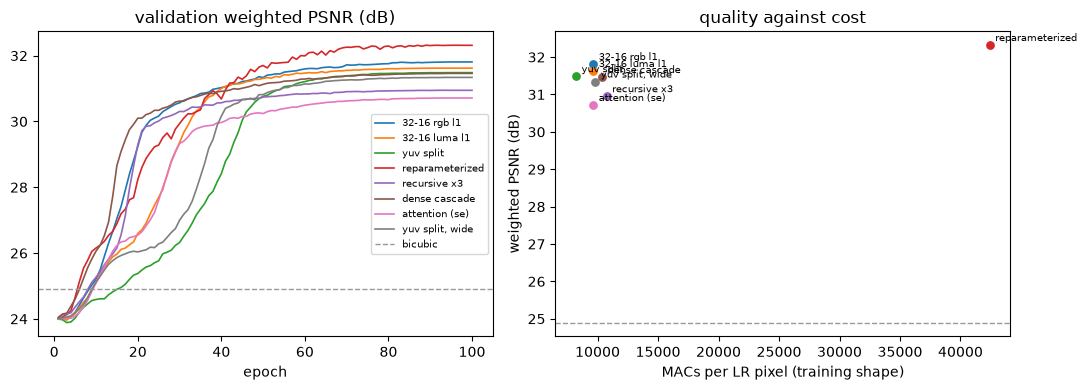

In [27]:
"""Training curves, and quality against cost."""

fig, (left, right) = plt.subplots(1, 2, figsize=(11, 4))
for name in STRATEGIES:
    left.plot(range(1, len(histories[name]) + 1),
              [entry["wpsnr"] for entry in histories[name]], label=name, linewidth=1.2)
left.axhline(baseline["wpsnr"], color="0.6", linestyle="--", linewidth=1, label="bicubic")
left.set_title("validation weighted PSNR (dB)")
left.set_xlabel("epoch")
left.legend(fontsize=7)

for name in STRATEGIES:
    cost = macs_per_lr_pixel(models[name])
    right.scatter(cost, results[name]["wpsnr"], s=28)
    right.annotate(name, (cost, results[name]["wpsnr"]), fontsize=7,
                   xytext=(4, 3), textcoords="offset points")
right.axhline(baseline["wpsnr"], color="0.6", linestyle="--", linewidth=1)
right.set_title("quality against cost")
right.set_xlabel("MACs per LR pixel (training shape)")
right.set_ylabel("weighted PSNR (dB)")

fig.tight_layout()
plt.show()

chroma moves further than luma in dB because it starts far quieter - a sixth of the
weight is what stops that from deciding the ranking


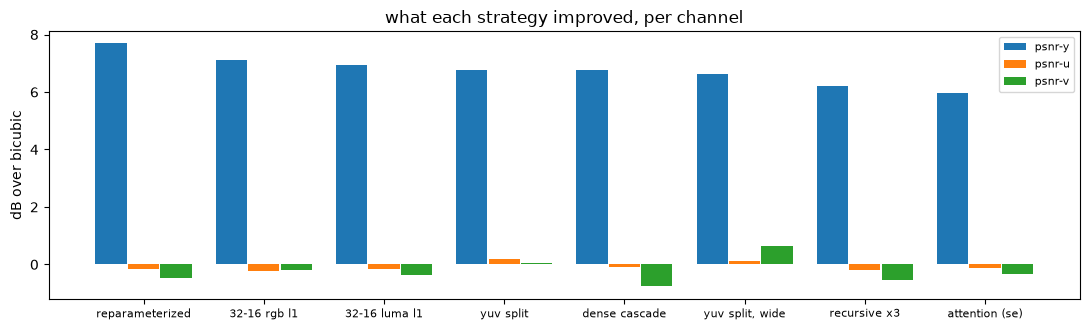

In [28]:
"""Where the gain landed: per channel, against the baseline."""

fig, ax = plt.subplots(figsize=(11, 3.4))
channels = ["y", "u", "v"]
positions = np.arange(len(order))
for index, channel in enumerate(channels):
    ax.bar(positions + index * 0.27 - 0.27,
           [results[name][channel] - baseline[channel] for name in order],
           width=0.26, label=f"psnr-{channel}")
ax.set_xticks(positions)
ax.set_xticklabels(order, fontsize=8)
ax.set_ylabel("dB over bicubic")
ax.set_title("what each strategy improved, per channel")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

print("chroma moves further than luma in dB because it starts far quieter - a sixth of the")
print("weight is what stops that from deciding the ranking")

### The collapse, checked

The reparameterized strategy is only worth anything if the three branches really do fold
into one convolution. Below: the collapsed model against the trained one on the same
input, and the two shapes side by side.

In [30]:
"""Collapse the trained branches and check the arithmetic survived."""

trained = models["reparameterized"]
collapsed = trained.collapsed().eval()
trained.eval()

sample = torch.rand(2, 3, manifest["patch_lr"], manifest["patch_lr"], device=DEVICE)
with torch.no_grad():
    difference = float((trained(sample) - collapsed(sample)).abs().max())
assert difference < 1e-5, f"the collapse is not the same operator ({difference:.2e})"

collapsed_scores = evaluate(collapsed, val_loader)
print(f"max abs difference {difference:.1e} on a patch pair")
print(f"{'':<14}{'params':>9}{'MACs/LR px':>12}{'wpsnr':>9}")
for name, model in [("trained", trained), ("collapsed", collapsed)]:
    scores = results["reparameterized"] if name == "trained" else collapsed_scores
    print(f"{name:<14}{sum(p.numel() for p in model.parameters()):9,}"
          f"{macs_per_lr_pixel(model):12,.0f}{scores['wpsnr']:9.2f}")

models["reparameterized (collapsed)"] = collapsed
results["reparameterized (collapsed)"] = collapsed_scores

max abs difference 3.0e-07 on a patch pair
                 params  MACs/LR px    wpsnr
trained          42,564      42,408    32.32
collapsed         9,696       9,636    32.32


### What it looks like, and where the error is

The error map is per channel and it is the argument for the whole measurement change: an
upscaler's mistakes are overwhelmingly in luma, at edges, and the chroma error is a faint
wash that no one would see. A metric that counts them equally is spending its dynamic
range on the wash.

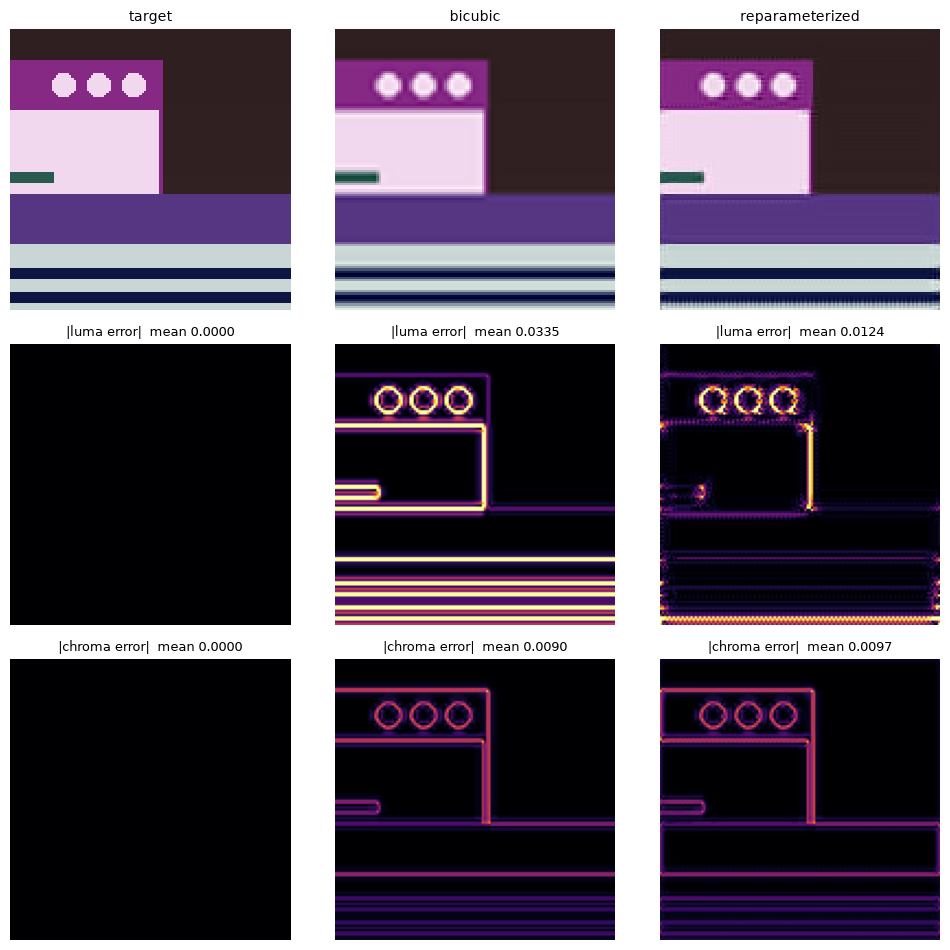

In [32]:
"""Bicubic, the best strategy and the target, with the luma and chroma error under them."""

@torch.no_grad()
def error_panels(model, index=3):
    lr = to_tensor(val_lr[index]).to(DEVICE)
    hr = to_tensor(val_hr[index]).to(DEVICE)
    predictions = {"bicubic": bicubic(lr), best_name: model(lr).clamp(0, 1)}

    fig, axes = plt.subplots(3, 3, figsize=(10, 9.6))
    for column, (name, prediction) in enumerate([("target", hr), *predictions.items()]):
        axes[0][column].imshow(prediction[0].clamp(0, 1).cpu().permute(1, 2, 0).numpy(),
                               interpolation="nearest")
        axes[0][column].set_title(name, fontsize=10)
        error = (metrics.rgb_to_yuv(prediction.clamp(0, 1)) - metrics.rgb_to_yuv(hr))[0].cpu()
        for row, (label, plane) in enumerate([("|luma error|", error[0].abs()),
                                              ("|chroma error|", error[1:].abs().sum(0))]):
            axes[row + 1][column].imshow(plane.numpy(), cmap="inferno", vmin=0, vmax=0.15)
            axes[row + 1][column].set_title(f"{label}  mean {plane.mean():.4f}", fontsize=9)
    for row in axes:
        for ax in row:
            ax.axis("off")
    fig.tight_layout()
    plt.show()


error_panels(models[best_name])

## 5. Checkpoint and export

The best strategy is saved with everything needed to rebuild it, loaded back into a fresh
model and checked three ways — same tensors, same output, same score — and then published
to the benchmark page beside the control it beat, at float32 and float16.

The tile a graph is pinned to is the page's step plus twice the model's own halo, so a
strategy with a longer reach is exported on a larger tile and keeps the same 128 output
pixels. That is the halo doing its job: geometry follows the architecture, not the other
way round.

In [34]:
"""Save the winner, load it back, and check it is the same model."""

BUILDERS = {"Baseline": Baseline, "YuvSplit": YuvSplit, "Reparameterized": Reparameterized,
            "Recursive": Recursive, "Dense": Dense, "Attention": Attention}

winner = models[best_name]
architecture = type(winner).__name__
checkpoint_path = CHECKPOINT_DIR / "upscale_strategies.pt"
torch.save({
    "architecture": architecture,
    "arguments": STRATEGIES[best_name][1],
    "strategy": best_name,
    "state_dict": winner.state_dict(),
    "scale": SCALE,
    "halo": winner.halo,
    "epochs": EPOCHS,
    "metric": f"weighted {':'.join(str(int(w)) for w in metrics.WEIGHTS)} Y:U:V",
    "val": results[best_name],
    "val_bicubic": baseline,
    "degradation": manifest["degradation"],
    "trained": time.strftime("%Y-%m-%dT%H:%M:%S"),
}, checkpoint_path)

checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=True)
restored = BUILDERS[checkpoint["architecture"]](**checkpoint["arguments"]).to(DEVICE)
restored.load_state_dict(checkpoint["state_dict"])
restored.eval()

with torch.no_grad():
    difference = float((winner.eval()(sample) - restored(sample)).abs().max())
assert difference <= 1e-6, f"the loaded model computes something else ({difference:.2e})"
reloaded = evaluate(restored, val_loader)
assert abs(reloaded["wpsnr"] - results[best_name]["wpsnr"]) < 0.01, "the stored score is not this model's"

print(f"{checkpoint_path.resolve()}  ({checkpoint_path.stat().st_size / 1e6:.2f} MB)")
for key, value in checkpoint.items():
    if key not in ("state_dict", "val", "val_bicubic"):
        print(f"{key:<14} {value}")
print(f"\nreloaded identical (max abs difference {difference:.1e}), "
      f"weighted PSNR {reloaded['wpsnr']:.2f} dB")

C:\Users\henrik\Downloads\desktop-streamer\model\upscale\checkpoints\upscale_strategies.pt  (0.18 MB)
architecture   Reparameterized
arguments      {}
strategy       reparameterized
scale          2
halo           4
epochs         100
metric         weighted 6:1:1 Y:U:V
degradation    bicubic downscale
trained        2026-09-04T18:03:39

reloaded identical (max abs difference 0.0e+00), weighted PSNR 32.32 dB


In [35]:
"""Export the published strategies, check each graph against torch, and time it."""

import onnxruntime as ort


def time_graph(path, size, dtype=np.float32, seconds=0.4):
    """Milliseconds per tile through onnxruntime, on the input the graph was pinned to."""
    options = ort.SessionOptions()
    options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    session = ort.InferenceSession(str(path), options, providers=["CPUExecutionProvider"])
    name = session.get_inputs()[0].name
    tile = np.random.rand(1, 3, size, size).astype(dtype)
    for _ in range(3):
        session.run(None, {name: tile})

    started, runs = time.perf_counter(), 0
    while time.perf_counter() - started < seconds:
        session.run(None, {name: tile})
        runs += 1
    return (time.perf_counter() - started) / runs * 1000


def check_graph(path, model, size, dtype=np.float32, tolerance=2e-3):
    options = ort.SessionOptions()
    options.graph_optimization_level = ort.GraphOptimizationLevel.ORT_ENABLE_ALL
    session = ort.InferenceSession(str(path), options, providers=["CPUExecutionProvider"])
    tile = np.random.rand(1, 3, size, size).astype(np.float32)
    expected = model.to("cpu").eval()(torch.from_numpy(tile)).detach().numpy()
    actual = session.run(None, {session.get_inputs()[0].name: tile.astype(dtype)})[0]
    difference = float(np.abs(expected - actual.astype(np.float32)).max())
    assert difference < tolerance, f"{path.name} computes something else: {difference:.2e}"
    return difference


# One graph per architecture: the top two rows are often the same shape under two losses,
# and a second copy of a shape the page already has is not a candidate.
published, shapes = [], set()
for name in order:
    shape = STRATEGIES[name][0]
    if shape in shapes:
        continue
    shapes.add(shape)
    published.append("reparameterized (collapsed)" if name == "reparameterized" else name)
    if len(published) == PUBLISH:
        break

print(f"{'model':<42}{'KB':>7}{'ms/tile':>10}{'vs torch':>11}   ops")
exported = {}
for name in published:
    model = models[name].to("cpu").eval()
    slug = name.replace(" (collapsed)", "").replace(" ", "_")
    size = webexport.TILE_STEP + 2 * model.halo

    info = webexport.export(model, f"upscale_{slug}_tile{webexport.TILE_STEP}.onnx", size,
                            label=f"{name} fp32", halo=model.halo)
    half = webexport.to_float16(info, f"upscale_{slug}_fp16_tile{webexport.TILE_STEP}.onnx")
    webexport.write_metadata(half["path"], {"label": f"{name} fp16"})

    for candidate, dtype, tolerance in [(info, np.float32, 2e-3), (half, np.float16, 4e-3)]:
        milliseconds = time_graph(candidate["path"], size, dtype)
        webexport.annotate(candidate, cpu_ms=round(milliseconds, 2))
        outside = (f"   outside the budget: {', '.join(candidate['outside_budget'])}"
                   if candidate["outside_budget"] else "")
        print(f"{candidate['path'].name:<42}{candidate['kb']:7.1f}{milliseconds:10.2f}"
              f"{check_graph(candidate['path'], model, size, dtype, tolerance):11.1e}"
              f"   {', '.join(f'{op}x{n}' for op, n in sorted(candidate['ops'].items()))}{outside}")
    exported[name] = (info, half)
    models[name].to(DEVICE)

print(f"\nwritten to {webexport.MODELS_DIR.resolve()}")

model                                          KB   ms/tile   vs torch   ops
upscale_reparameterized_tile128.onnx         39.3      0.93    2.4e-07   Addx1, Convx4, DepthToSpacex1, Relux2
upscale_reparameterized_fp16_tile128.onnx    20.7      1.00    8.4e-04   Addx1, Convx4, DepthToSpacex1, Relux2
upscale_32-16_rgb_l1_tile128.onnx            39.3      0.95    1.2e-07   Addx1, Convx4, DepthToSpacex1, Relux2
upscale_32-16_rgb_l1_fp16_tile128.onnx       20.7      1.07    8.8e-04   Addx1, Convx4, DepthToSpacex1, Relux2

written to C:\Users\henrik\Downloads\desktop-streamer\model\upscale\benchmark\www\models


In [36]:
"""One whole frame through the winner, against bicubic, with a ground truth."""

@torch.no_grad()
def upscale_image(model, image):
    x = torch.from_numpy(np.asarray(image.convert("RGB")).transpose(2, 0, 1).copy())
    x = x.float().div_(255.0).unsqueeze(0).to(DEVICE)
    return model.to(DEVICE)(x).clamp(0, 1)


source = sorted(RAW_DIR.glob("*.png"))[0]
truth = Image.open(source).convert("RGB")
truth = truth.crop((0, 0, truth.width - truth.width % SCALE, truth.height - truth.height % SCALE))
small = truth.resize((truth.width // SCALE, truth.height // SCALE), Image.BICUBIC)

target = to_tensor(np.asarray(truth)).to(DEVICE)
frame = upscale_image(restored, small)
Image.fromarray((frame[0].cpu().permute(1, 2, 0).numpy() * 255).round().astype(np.uint8)) \
    .save(SAMPLE_DIR / "upscaled_strategies.png")

print(f"{source.name}  {small.size} -> {tuple(frame.shape[2:])[::-1]}")
print(f"{'':<12}{metrics.HEADER}")
print(f"{'bicubic':<12}{metrics.row(metrics.report(bicubic(to_tensor(np.asarray(small)).to(DEVICE)), target))}")
print(f"{best_name:<12}{metrics.row(metrics.report(frame, target))}")

synthetic_0000.png  (480, 300) -> (960, 600)
                wpsnr   psnr-y   psnr-u   psnr-v  psnr-rgb   ssim-y
bicubic         25.82    25.09    29.55    29.01     23.92   0.9437
reparameterized    28.15    27.83    29.57    29.03     25.46   0.9657


## What the eight runs said

The ranking is above and it is the least of what came out of this. The result is the row
underneath it: **the same strategy, trained three times at three seeds, lands 0.61 dB
apart.** Nothing else changed — same data, same recipe, same 100 epochs; only the draw.

That number is the ruler every other number here has to be read against, and it is wider
than most of the table:

- **Reparameterization leads by 0.51 dB over the control, which is inside the band.** It
  is unbeaten rather than proven, and it is still the one to take, because the thing it
  wins is free: it collapses to the reference model's exact graph — `Conv`×4, `Add`,
  `DepthToSpace`, checked at 3.0e-07 — so a gain that might be luck costs nothing if it
  is. Every other strategy is asking to be paid for.
- **Six of the seven contenders are beaten by more than the noise**, so those rows are
  decided: recursion, attention, both colour splits, the dense cascade and the
  luma-weighted control all lose to the reference shape by more than a coin toss.
- **The objective made no measurable difference.** Luma-weighted L1 lands 0.19 dB below
  RGB L1 — a third of the noise band, so the honest reading is *no effect*. The reason is
  worth keeping: RGB L1 is *already* mostly a luma loss. Y is 0.21R + 0.72G + 0.07B and
  the three channels of a desktop frame move together, so an RGB error is a luma error
  wearing a hat, and reweighting it by 6:1:1 moves the gradient less than it looks like
  it should. The metric had to change; the loss did not have to follow.
- **Splitting the colour does exactly what it was designed to do, and the trade is bad.**
  Both split variants own the chroma columns — 38.92/38.56 dB for the narrow one, and
  39.16 dB of `psnr-v` for the wide one, the best chroma in the table — and both give up
  more luma than the chroma is worth at a weighting of six to one. It is a strategy built
  from the metric that the metric then rejects, which is the cleanest kind of negative
  result available here.
- **Attention is the worst row and it also breaks the halo.** −1.10 dB, `Sigmoid` and
  `Mul` outside the WebGPU op budget, and a pooled gate that makes an output pixel depend
  on the whole tile — so two tilings of one frame disagree, and the halo stops being a
  complete account of the tiling error. Three reasons, one direction.

And a correction the noise floor forces on this folder: `upscale_web.ipynb` reads its
width ladder to ±0.15 dB, on the strength of one pair of runs. Three runs here say the
spread is four times that. Several of the gaps in that ladder are inside it, which does
not overturn its choice of shape — a third of the MACs for 1.2 dB is still the trade it
was — but it does mean the rungs closest together were never distinguishable.

Read every dB with the dataset in mind, as ever: twelve synthetic frames of drawn windows
and text, degraded by a clean bicubic downscale, is a narrow and very learnable
distribution, and 76 validation patches from two held-out frames is what all of this is
being measured on. That split is now the binding constraint — not the architectures, and
not the metric.

Next, in order: **more validation frames**, because a 0.61 dB noise floor cannot resolve
anything this notebook wants to ask; then the same eight runs on real screen captures with
a codec in the degradation; then the winner re-exported at the tile step the browser sweep
argues for, and measured in the browser, since the `ms/tile` here is a CPU runtime and
`upscale_web` has already shown that CPU and WebGPU disagree about which operators are
expensive.